In [1]:
ROOT = '/kaggle/input/datasets/keerthanasrinivasan5/grain-classification-dataset-5-classes/Grams/'
TEST = ROOT + 'test'
TRAIN = ROOT + 'train'
VALID = ROOT + 'valid'

We want to use image embeddings for EDA and classification, so let's add code to get some for us using ResNeXt without fine-tuning.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 143MB/s]


Let's load up our data. This will take nearly nine minutes, but it's definitely worth the wait.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (48, 48)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(list(iglob(pathname=arg))) ]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder)}
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in tqdm.tqdm(desc='train classes', iterable=train_dict.items())]))
test_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TEST + '/*') if isdir(folder)}
test_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in tqdm.tqdm(desc='test classes', iterable=test_dict.items())]))
val_dict = {basename(folder) : folder + '/*.*' for folder in iglob(VALID + '/*') if isdir(folder)}
val_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in tqdm.tqdm(desc='val classes', iterable=val_dict.items())]))
train_df = pd.concat(axis='index', objs=[train_df, val_df])
train_df['tag'] = train_df['tag'].str.replace('_', ' ')
test_df['tag'] = test_df['tag'].str.replace('_', ' ')
print('done in {}'.format(arrow.now() - time_start))

val classes: 100%|██████████| 5/5 [00:51<00:00, 10.33s/it]

done in 0:09:13.460692


Are our classes balanced in our training data? Almost.

In [4]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,Wheat,Green gram,Black gram,Dhal,Chenna
proportion,0.216085,0.202519,0.195736,0.195736,0.189922


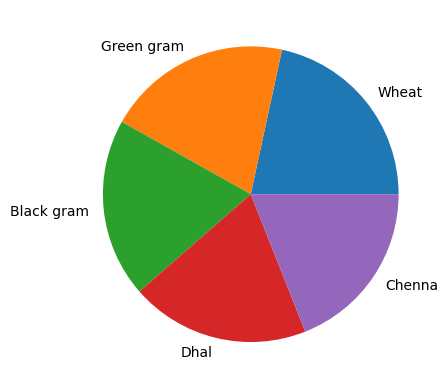

In [5]:
import matplotlib.pyplot as plt

train_df['tag'].value_counts(normalize=False).to_frame().plot.pie(y='count')
plt.ylabel('')
plt.legend().remove()
plt.show()

Are our classes balanced in our test data? Almost, but they are differently imbalanced than they are in our training data.

In [6]:
test_df['tag'].value_counts(normalize=True).to_frame().T

tag,Green gram,Wheat,Black gram,Dhal,Chenna
proportion,0.206897,0.206897,0.198276,0.198276,0.189655


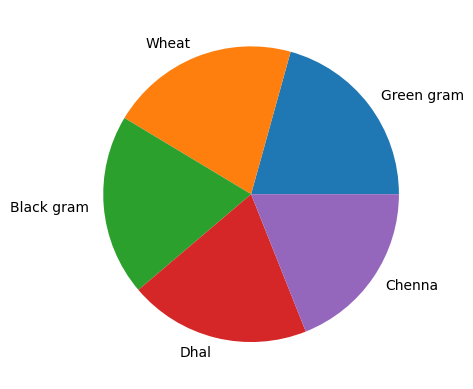

In [7]:
test_df['tag'].value_counts(normalize=False).to_frame().plot.pie(y='count')
plt.ylabel('')
plt.legend().remove()
plt.show()

Let's use TSNE to add x/y coordinates based on our image embeddings for both our training data and our test data.

In [8]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))
test_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
test_df[['x', 'y']] = test_reducer.fit_transform(X=test_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1032 samples in 0.008s...
[t-SNE] Computed neighbors for 1032 samples in 0.219s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1032
[t-SNE] Computed conditional probabilities for sample 1032 / 1032
[t-SNE] Mean sigma: 4.461729
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.164803
[t-SNE] KL divergence after 1000 iterations: 0.397959
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 116 samples in 0.001s...
[t-SNE] Computed neighbors for 116 samples in 0.007s...
[t-SNE] Computed conditional probabilities for sample 116 / 116
[t-SNE] Mean sigma: 7.475176
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.064415
[t-SNE] KL divergence after 1000 iterations: 0.132202


Let's plot our training data.

In [9]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: grain', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

What do we see? We see that our data mostly clusters in tight, distinct clusters, but there are some marginal/difficult cases. Let's build a model and see what we get.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

logreg = LogisticRegression(max_iter=1000, tol=1e-12, verbose=0, ).fit(train_df['value'].apply(func=pd.Series), train_df['tag'],)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series)))))
print(classification_report(zero_division=0.0, y_true=test_df['tag'], y_pred=logreg.predict(X=test_df['value'].apply(func=pd.Series))))

model fit in 409 iterations
accuracy: 0.8793
f1: 0.8725
              precision    recall  f1-score   support

  Black gram       0.79      1.00      0.88        23
      Chenna       0.81      1.00      0.90        22
        Dhal       0.86      0.83      0.84        23
  Green gram       1.00      0.58      0.74        24
       Wheat       1.00      1.00      1.00        24

    accuracy                           0.88       116
   macro avg       0.89      0.88      0.87       116
weighted avg       0.90      0.88      0.87       116



Our overall f1 score is kind of disappointing given that some of our class and precision recall scores are perfect. Let's look at our model probabilities.

<Axes: xlabel='probability', ylabel='Count'>

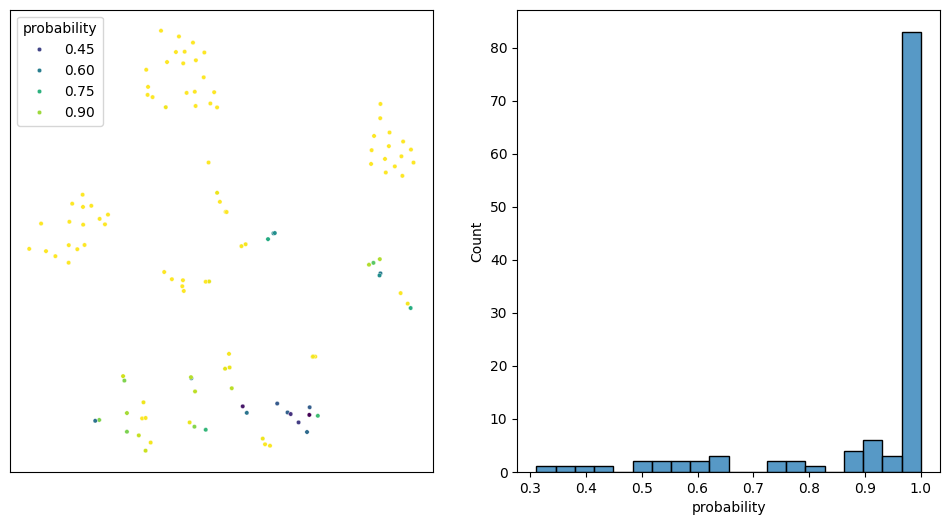

In [11]:
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = test_df[['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=test_df['value'].apply(func=pd.Series)), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=10)
ax[0].set(xlabel=None)
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)

It looks like our test data is out of sample, and as a result our model probabilities show up in a few isolated clusters, rather than along cluster boundaries, where we might expect them to be based on our training data.